In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
jungle_dir = '/kaggle/input/datasets/andy8744/udacity-self-driving-car-behavioural-cloning/self_driving_car_dataset_jungle/'
make_dir = '/kaggle/input/datasets/andy8744/udacity-self-driving-car-behavioural-cloning/self_driving_car_dataset_make/'

columns = ['center', 'left', 'right', 'steering', 'throttle', 'reverse', 'speed']

df_jungle = pd.read_csv(os.path.join(jungle_dir, 'driving_log.csv'), names=columns, header=None)

df_make = pd.read_csv(os.path.join(make_dir, 'driving_log.csv'), names=columns, header=None)

**CHECK THE FORMAT OF THE FIRST 03 COLUMNS OF THE ATTACHED 'driving_log.csv' FILE IN THE DATA CARD IN ORDER TO UNDERSTAND THE IMPORTANCE OF THE FOLLOWING FUNCTION!**

In [4]:
def path_refiner(raw_path, track_kaggle_root):
    
    # Extracts just the file name like: 'center_2022_04_10_12_44_27_913.jpg'
    filename = raw_path.strip().replace('\\', '/').split('/')[-1]
    
    return os.path.join(track_kaggle_root, 'IMG', filename)

for col in ['center', 'left', 'right']:
    df_jungle[col] = df_jungle[col].apply(lambda x: path_refiner(x, jungle_dir))

for col in ['center', 'left', 'right']:
    df_make[col] = df_make[col].apply(lambda x: path_refiner(x, make_dir))

In [5]:
df_master = pd.concat([df_jungle, df_make], ignore_index=True)

In [6]:
df_master.head()

,center,left,right,steering,throttle,reverse,speed
0,/kaggle/input/datasets/andy8744/udacity-self-d...,/kaggle/input/datasets/andy8744/udacity-self-d...,/kaggle/input/datasets/andy8744/udacity-self-d...,0.00,1.0,0,21.69488
1,/kaggle/input/datasets/andy8744/udacity-self-d...,/kaggle/input/datasets/andy8744/udacity-self-d...,/kaggle/input/datasets/andy8744/udacity-self-d...,0.00,1.0,0,22.50011
2,/kaggle/input/datasets/andy8744/udacity-self-d...,/kaggle/input/datasets/andy8744/udacity-self-d...,/kaggle/input/datasets/andy8744/udacity-self-d...,0.00,1.0,0,23.11461
3,/kaggle/input/datasets/andy8744/udacity-self-d...,/kaggle/input/datasets/andy8744/udacity-self-d...,/kaggle/input/datasets/andy8744/udacity-self-d...,0.00,1.0,0,23.89061
4,/kaggle/input/datasets/andy8744/udacity-self-d...,/kaggle/input/datasets/andy8744/udacity-self-d...,/kaggle/input/datasets/andy8744/udacity-self-d...,0.05,1.0,0,24.46815


**CHECKING IF THEIR ARE LOTS OF STEERING VALUES AT 0.0 ANGLE WHICH MAY CAUSE CLASS IMBALANCE WHILE TRAINING AS USUALLY THE DRIVER TAKES LESS FREQUENT LEFT, RIGHT TURNS AND GOES STRAIGHT MOST OF THE TIME WHICH MAKES THE SETEERING ANGLE AT 0.0 MOST OF THE TIME!**

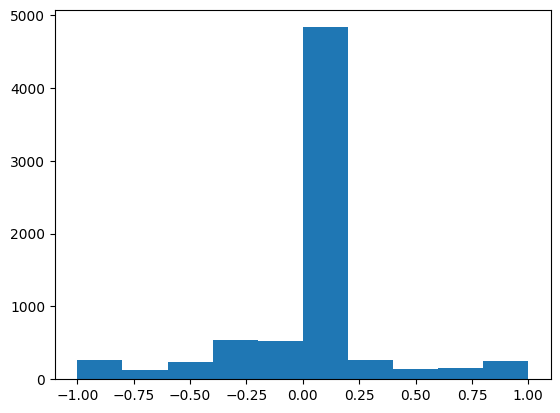

In [7]:
plt.hist(df_master['steering'])

plt.show()

**FIXING THE STEERING SKEWNESS**

In [8]:
zero_steering_df = df_master[df_master['steering'] == 0.0]
non_zero_steering_df = df_master[df_master['steering'] != 0.0]

print("NUM OF ROWS WHERE STEERING IS 0 :  ", len(zero_steering_df))
print("NUM OF ROWS WHERE STEERING IS NOT 0 :  ", len(non_zero_steering_df))

NUM OF ROWS WHERE STEERING IS 0 :   4532
NUM OF ROWS WHERE STEERING IS NOT 0 :   2802


In [9]:
# KEEPING ONLY 20% OF THE ROWS FROM THE ZERO-STEERING IN-ORDER TO AVOID CLASS IMBALANCE CAUSED BY THOSE 0 STEERING VALUES:

zero_steering_downsampled = zero_steering_df.sample(frac=0.2, random_state=42)

# BALANCING THE DATASET NOW BY COMBINING THE ONLY 20% 0F THE ZERO-VALUED STEERING VALUES WITH THE REMAINING NON-ZERO ONES

df_balanced = pd.concat([zero_steering_downsampled, non_zero_steering_df], ignore_index=True)

In [10]:
print(f"\nBalanced 0.0 steering rows: {len(zero_steering_downsampled)}")
print(f"Total rows in df_balanced: {len(df_balanced)}")


Balanced 0.0 steering rows: 906
Total rows in df_balanced: 3708


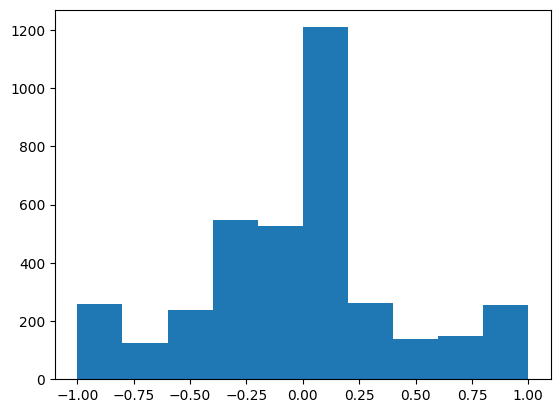

In [11]:
plt.hist(df_balanced['steering'])

plt.show()

# THE ZERO STEERING VALUES ARE STILL DOMINATING BUT NOT SKEWING THE WHOLE DATASET LIKE BEFORE.
# THIS ONE IS ACCEPTABLE AS THE CAT NATURALLY REMAINS AT THE CENTER MORE OFTEN COMPARED TO LEFT, RIGHT TURNS.

In [12]:
# NOW SPLITTING THE DATASET FOR MODEL-TRAINING AND VALIDATION

from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df_balanced, test_size=0.2, random_state=42)

In [13]:
# DEFININF THE CUSTOM DATASET CLASS

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image

class MyDataset(Dataset):
    def __init__(self, dataframe, transform=None, is_training=True):
        self.df = dataframe
        self.transform = transform
        self.is_training = is_training
        self.steering_correction = 0.3  
        
        # For the Left Camera view (which looks like the car is drifting left), we add +0.3 
        # to force the model to learn to steer Right back to safety. 
        # For the Right Camera view (which looks like the car is drifting right), we subtract -0.3 
        # to force the model to learn to steer Left back to the center of the lane.
        
    def __len__(self):
        return len(self.df) * 3 if self.is_training else len(self.df)

    def __getitem__(self, idx):
        if self.is_training:
            row_idx = idx // 3
            cam_type = idx % 3  # 0: center, 1: left, 2: right 
        else:
            row_idx = idx
            cam_type = 0  

        row = self.df.iloc[row_idx]
        img_full_path = row.iloc[cam_type] 
        
        # Loading the image
        image = Image.open(img_full_path).convert('RGB')
        steering = float(row['steering'])

        # Applying camera correction offsets
        if self.is_training:
            if cam_type == 1:    
                steering += self.steering_correction
            elif cam_type == 2:  
                steering -= self.steering_correction

        # Augmentation: Horizontally flipping images for better generalization at both tracks
        if self.is_training and np.random.rand() > 0.5:
            image = image.transpose(Image.FLIP_LEFT_RIGHT)
            steering = -steering
        
        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(steering, dtype=torch.float32)

In [14]:
# SETTING ADDITIONAL TRANSFORMATIONS FOR THE TRAIN AND VAL SETS

train_transforms = transforms.Compose([
    # CROPPING TO FOCUS MAINLY ON THE ROAD / ASPHALT
    transforms.Lambda(lambda img: transforms.functional.crop(img, top=60, left=0, height=80, width=320)),
    transforms.Resize((66, 200)),                    
    transforms.ColorJitter(brightness=0.5, contrast=0.5), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    # CROPPING TO FOCUS MAINLY ON THE ROAD / ASPHALT
    transforms.Lambda(lambda img: transforms.functional.crop(img, top=60, left=0, height=80, width=320)),
    transforms.Resize((66, 200)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [15]:
# SETTING THE TRAIN,VAL DATASETS AND DATALOADERS

train_dataset = MyDataset(train_df, transform=train_transforms, is_training=True)
val_dataset = MyDataset(val_df, transform=val_transforms, is_training=False)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4)

In [16]:
print(f"Total training batches per epoch: {len(train_loader)}")
print(f"Total validation batches per epoch: {len(val_loader)}")

Total training batches per epoch: 139
Total validation batches per epoch: 12


In [17]:
# DEFINING THE NVIDIDA INSPIRED ARCHITECURE FOR BEHAVIORIAL CLONING FOR SELF-DRIVING CARS

import torch.nn as nn

class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 24, kernel_size=5, stride=2),
            nn.ELU(), 
            
            nn.Conv2d(24, 36, kernel_size=5, stride=2),
            nn.ELU(),
            
            nn.Conv2d(36, 48, kernel_size=5, stride=2),
            nn.ELU(),
            
            nn.Conv2d(48, 64, kernel_size=3),
            nn.ELU(),
            
            nn.Conv2d(64, 64, kernel_size=3),
            nn.ELU()
        )
        
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5), # For better generalization between Jungle and Lake tracks
            
            nn.Linear(64 * 1 * 18, 100), 
            nn.ELU(),
            
            nn.Linear(100, 50),
            nn.ELU(),
            
            nn.Linear(50, 10),
            nn.ELU(),
            
            nn.Linear(10, 1)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [18]:
device = ("cuda" if torch.cuda.is_available else "cpu")

print(device)

cuda


In [19]:
model = MyModel()

In [20]:
model = model.to(device)

model = nn.DataParallel(model)

In [21]:
import torch.optim as optim

# Setting the Loss
criterion = nn.MSELoss()

# Setting the optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Setting the scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min',      
    factor=0.5,      
    patience=2,     
)

In [22]:
# TRAINING THE MODEL...

epochs = 100
best_val_loss = float('inf')

# For Early Stopping 
patience = 15
patience_counter = 0

print("Starting Training Loop...\n")

for epoch in range(epochs):
    
    # TRAINING PHASE...
    
    model.train() 
    train_loss = 0.0
    train_absolute_error = 0.0
    
    for images, steering_labels in train_loader:

        # MOVING IMAGES, LABELS TO GPU FOR FAST TRAINING
        images = images.to(device)
        steering_labels = steering_labels.to(device).view(-1, 1)
        
        # Forward Pass
        outputs = model(images)
        
        # CALCULATING LOSS
        loss = criterion(outputs, steering_labels)
        
        # Backward Pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track total squared loss
        train_loss += loss.item() * images.size(0)
        
        # Track total absolute distance error |Guess - Target|
        batch_mae = torch.abs(outputs - steering_labels).sum().item()
        train_absolute_error += batch_mae
        
    total_train_loss = train_loss / len(train_loader.dataset)
    avg_train_mae = train_absolute_error / len(train_loader.dataset)

    # VALIDATION PHASE...
    
    model.eval() 
    val_loss = 0.0
    val_absolute_error = 0.0
    
    with torch.no_grad(): 
        
        for images, steering_labels in val_loader:
            
            # MOVING IMAGES AND LABELS TO GPU
            images = images.to(device)
            steering_labels = steering_labels.to(device).view(-1, 1)
            
            # FORWARD PASS
            outputs = model(images)
            
            # CALCULATING LOSS
            loss = criterion(outputs, steering_labels)
            
            val_loss += loss.item() * images.size(0)
            
            batch_mae = torch.abs(outputs - steering_labels).sum().item()
            val_absolute_error += batch_mae
            
    total_val_loss = val_loss / len(val_loader.dataset)
    avg_val_mae = val_absolute_error / len(val_loader.dataset)
    
    print(f"Epoch [{epoch+1}/{epochs}] \n"
          f"Train Loss (MSE): {total_train_loss:.5f} | Val Loss (MSE): {total_val_loss:.5f} || "
          f"Train MAE: {avg_train_mae:.5f} | Val MAE: {avg_val_mae:.5f}")

    # SCHEDULER
    scheduler.step(total_val_loss)

    # Saving the best model based on best val_loss & Early Stopping check
    if total_val_loss < best_val_loss:
        best_val_loss = total_val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print("New best model saved!")
        patience_counter = 0  
    else:
        patience_counter += 1 
        print(f"Early stopping counter: {patience_counter}/{patience}")
        
    if patience_counter >= patience:
        print(f"\nEarly stopping the training at epoch {epoch+1}!")
        break
        
print("\nTraining Complete!")

Starting Training Loop...

Epoch [1/100] 
Train Loss (MSE): 0.18208 | Val Loss (MSE): 0.11119 || Train MAE: 0.32971 | Val MAE: 0.26165
New best model saved!
Epoch [2/100] 
Train Loss (MSE): 0.14193 | Val Loss (MSE): 0.10628 || Train MAE: 0.29115 | Val MAE: 0.25327
New best model saved!
Epoch [3/100] 
Train Loss (MSE): 0.13607 | Val Loss (MSE): 0.09764 || Train MAE: 0.28375 | Val MAE: 0.24327
New best model saved!
Epoch [4/100] 
Train Loss (MSE): 0.13187 | Val Loss (MSE): 0.10056 || Train MAE: 0.28025 | Val MAE: 0.24422
Early stopping counter: 1/15
Epoch [5/100] 
Train Loss (MSE): 0.12493 | Val Loss (MSE): 0.09482 || Train MAE: 0.27240 | Val MAE: 0.23451
New best model saved!
Epoch [6/100] 
Train Loss (MSE): 0.12288 | Val Loss (MSE): 0.09711 || Train MAE: 0.26974 | Val MAE: 0.23870
Early stopping counter: 1/15
Epoch [7/100] 
Train Loss (MSE): 0.11805 | Val Loss (MSE): 0.09241 || Train MAE: 0.26312 | Val MAE: 0.23154
New best model saved!
Epoch [8/100] 
Train Loss (MSE): 0.11704 | Val Lo

**THANK YOU!**